# The Groovy Commutator: from one rule to pairs of rules

Narrated walkthrough. Origin: https://liet-codes.github.io/wet-math/commutator.html

This notebook reconstructs the path from the original single-rule construction
through to the pairwise / cross-rule generalization, with the actual results
found along the way (not idealized — including the places a clean story broke).
For the full citation list and the QM correspondence, see `../NOTES.md`. For
what's open to extend next, see `../CLAUDE.md`.


In [1]:
import sys
sys.path.insert(0, "../src")
import numpy as np
import matplotlib.pyplot as plt
from groovy import (
    apply_rule, C, D, E, G, cross_commutator, divergence_trajectory,
    compressibility, image_ratio, divergence_stats, WOLFRAM_CLASS, sweep,
)
rng = np.random.default_rng(0)


## 1. The single-rule commutator

For an elementary CA rule `phi`: `D(S) = S XOR phi(S)`, `E(S) = phi(S)`,
`G(S) = C(D(E(S)), E(D(S)))`.

`G` is literally the operator commutator `[D, E]` evaluated at S — not
just analogous to it.

**Claim to test**: G(S) is constant across every S iff `phi` is GF(2)-affine.


In [2]:
for rule, note in [
    (0,   "trivial"),
    (90,  "affine, no bias  -> predict G == 0 always"),
    (150, "affine, no bias  -> predict G == 0 always"),
    (165, "affine, WITH bias (complement of 90) -> predict G == nonzero constant"),
    (105, "affine, WITH bias (complement of 150) -> predict G == nonzero constant"),
    (110, "nonlinear, Class IV -> predict G state-dependent"),
    (30,  "nonlinear, Class III -> predict G state-dependent"),
]:
    samples = [G(rng.integers(0,2,size=64).astype('uint8'), rule) for _ in range(10)]
    is_const = all(np.array_equal(s, samples[0]) for s in samples)
    print(f"rule {rule:3d} ({note:55s}): G constant across S? {is_const!s:5s}  "
          f"mean density={np.mean([s.mean() for s in samples]):.3f}")


rule   0 (trivial                                                ): G constant across S? True   mean density=0.000
rule  90 (affine, no bias  -> predict G == 0 always              ): G constant across S? True   mean density=0.000
rule 150 (affine, no bias  -> predict G == 0 always              ): G constant across S? True   mean density=0.000
rule 165 (affine, WITH bias (complement of 90) -> predict G == nonzero constant): G constant across S? True   mean density=1.000
rule 105 (affine, WITH bias (complement of 150) -> predict G == nonzero constant): G constant across S? True   mean density=1.000
rule 110 (nonlinear, Class IV -> predict G state-dependent       ): G constant across S? False  mean density=0.303
rule  30 (nonlinear, Class III -> predict G state-dependent      ): G constant across S? False  mean density=0.420


Confirmed. The affine family (90, 150, 165, 105) gives a *constant* G —
either zero (no bias term) or a fixed nonzero array (with a bias term),
identical regardless of which random S you start from. The nonlinear rules
don't.

This is the discrete analog of the canonical commutation relation
`[x,p] = iħ` being a *constant operator* rather than a dynamical one — see
NOTES.md section 2 for the full correspondence (Ehrenfest's theorem, Noether,
quantum chaos spectral statistics, quantum scars).


## 2. Four single-rule regimes, visualized

Spacetime fields of G itself, across rules spanning: dead (G≡0), crystalline
(G≡nonzero constant), noisy (G≠0, incompressible), structured (G≠0, compressible).


rule   0: compressibility(G-field) = 0.010
rule 165: compressibility(G-field) = 0.010
rule  30: compressibility(G-field) = 0.949
rule 110: compressibility(G-field) = 0.829


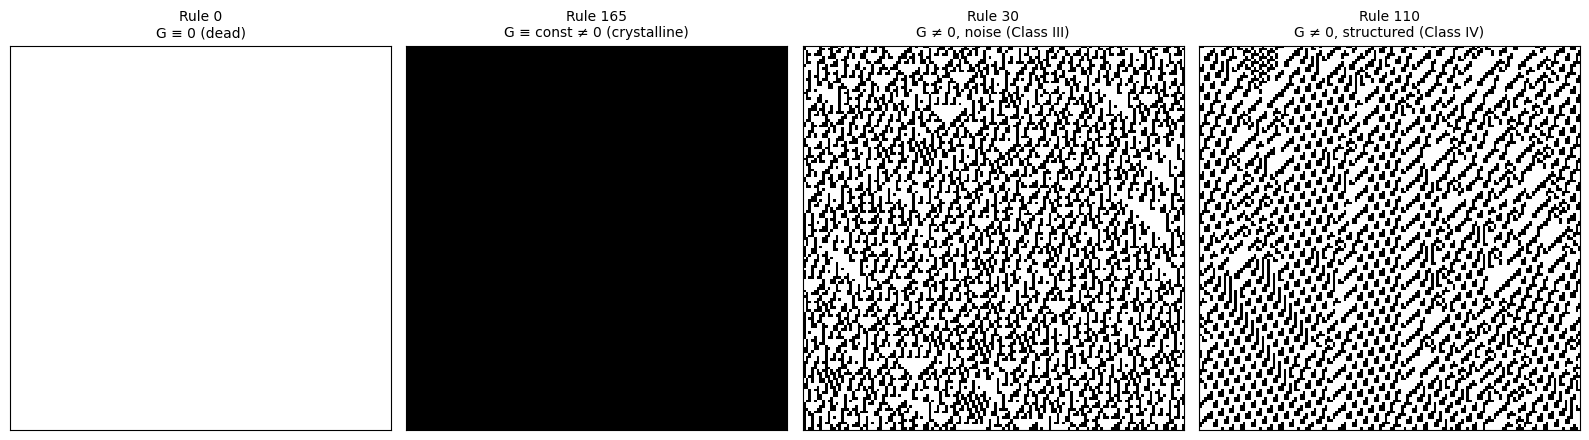

In [3]:
def G_spacetime(rule_num, n=140, steps=140, seed=7):
    rng = np.random.default_rng(seed)
    S = rng.integers(0, 2, size=n).astype('uint8')
    field = np.zeros((steps, n), dtype=np.uint8)
    for t in range(steps):
        field[t] = G(S, rule_num)
        S = apply_rule(S, rule_num)
    return field

fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
panels = [(0, "Rule 0\nG ≡ 0 (dead)"),
          (165, "Rule 165\nG ≡ const ≠ 0 (crystalline)"),
          (30, "Rule 30\nG ≠ 0, noise (Class III)"),
          (110, "Rule 110\nG ≠ 0, structured (Class IV)")]
for ax, (rule, title) in zip(axes, panels):
    field = G_spacetime(rule)
    ax.imshow(field, cmap="Greys", interpolation="nearest", aspect="auto", vmin=0, vmax=1)
    ax.set_title(title, fontsize=10); ax.set_xticks([]); ax.set_yticks([])
    print(f"rule {rule:3d}: compressibility(G-field) = {compressibility(field):.3f}")
plt.tight_layout()
plt.savefig("../results/four_regimes.png", dpi=140, bbox_inches="tight")
plt.show()


## 3. Cross-rule commutators: do TWO rules commute?

`cross_commutator(S) = C(phi_a(phi_b(S)), phi_b(phi_a(S)))`.

This is a real, solved, named problem: Moore & Boykett, "Commuting Cellular
Automata," *Complex Systems* 11(1), 1997. See NOTES.md section 3.


In [4]:
affine_family = [90, 150, 165, 105]

def always_commutes(a, b, n=80, trials=20, seed=3):
    rng = np.random.default_rng(seed)
    out = []
    for _ in range(trials):
        S = rng.integers(0,2,size=n).astype('uint8')
        out.append(cross_commutator(S, a, b))
    always0 = all(not g.any() for g in out)
    const = all(np.array_equal(g, out[0]) for g in out)
    return always0, const, np.mean([g.mean() for g in out])

print("affine x affine pairs:")
for i, a in enumerate(affine_family):
    for b in affine_family[i+1:]:
        always0, const, dens = always_commutes(a, b)
        print(f"  {a:3d} <-> {b:3d}:  commute={always0!s:5s}  state-independent-disagreement={const!s:5s}  density={dens:.3f}")


affine x affine pairs:
   90 <-> 150:  commute=True   state-independent-disagreement=True   density=0.000
   90 <-> 165:  commute=False  state-independent-disagreement=True   density=1.000
   90 <-> 105:  commute=False  state-independent-disagreement=True   density=1.000
  150 <-> 165:  commute=True   state-independent-disagreement=True   density=0.000
  150 <-> 105:  commute=True   state-independent-disagreement=True   density=0.000
  165 <-> 105:  commute=False  state-independent-disagreement=True   density=1.000


Within the affine family, pairs either fully commute (density 0) or disagree
by a **fixed constant**, never partially, never randomly — exactly the
kinematic/dynamical split from the single-rule case, now showing up between
rules instead of within one.


## 4. Five regimes for PAIRS — divergent unfoldings of one shared state

Same initial state S0. path1 = repeat(apply A, then B). path2 = repeat(apply
B, then A). Track their disagreement over time. This is the construction
that produces structure the single-rule case doesn't have at all.


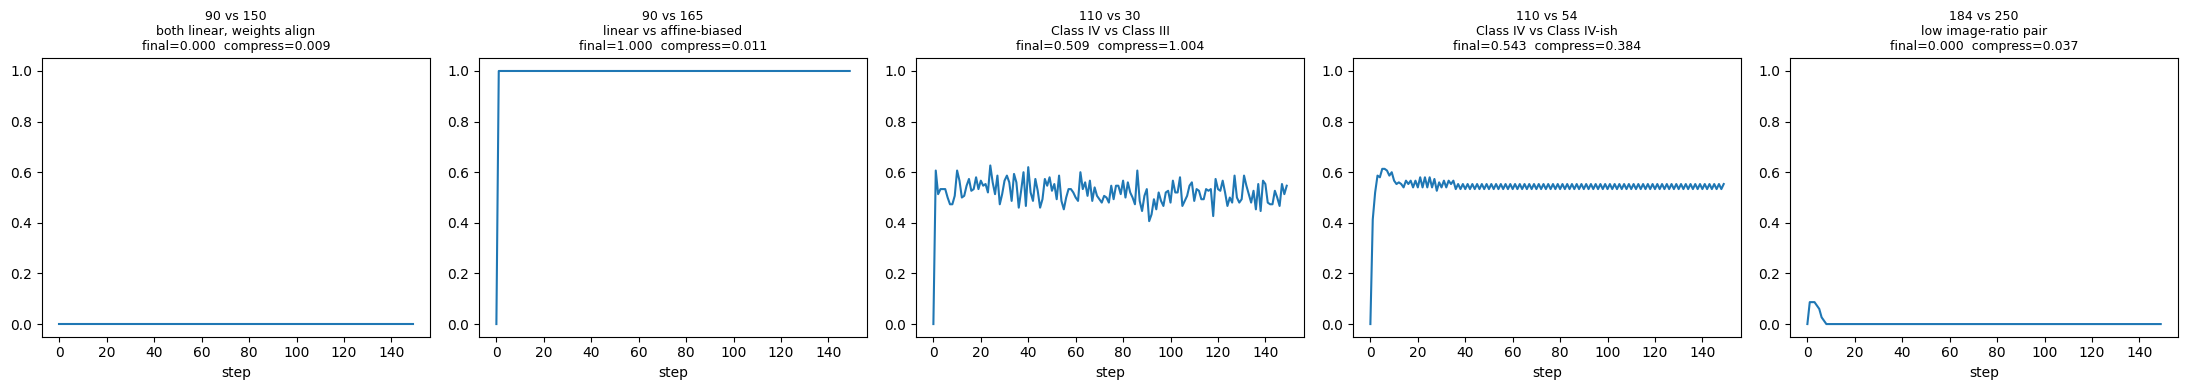

In [5]:
pairs = [(90, 150, "both linear, weights align"),
         (90, 165, "linear vs affine-biased"),
         (110, 30, "Class IV vs Class III"),
         (110, 54, "Class IV vs Class IV-ish"),
         (184, 250, "low image-ratio pair")]

fig, axes = plt.subplots(1, len(pairs), figsize=(22, 4))
for ax, (a, b, label) in zip(axes, pairs):
    field = divergence_trajectory(rng.integers(0,2,size=150).astype('uint8'), a, b, steps=150)
    stats = divergence_stats(field)
    dens = field.mean(axis=1)
    ax.plot(dens)
    ax.set_title(f"{a} vs {b}\n{label}\nfinal={stats['final']:.3f}  compress={stats['compressibility']:.3f}", fontsize=9)
    ax.set_ylim(-0.05, 1.05); ax.set_xlabel("step")
plt.tight_layout()
plt.savefig("../results/pair_divergence.png", dpi=140, bbox_inches="tight")
plt.show()


Five distinct shapes: **commute** (flat 0), **crystalline** (flat nonzero
constant), **noisy divergence** (settles ~0.5, compressibility near 1 —
indistinguishable from noise), **structured divergence** (settles ~0.5 but
compressibility well below 1 — a visible regular ripple; this is the new
regime, doesn't exist for a single rule), and **drain** (spikes then decays
to zero).

The drain regime looks like spontaneous agreement. It isn't — see next.


## 5. The drain mechanism: information loss, not coordination

Decisive test: two **completely unrelated** random initial states (not the
same S0 at all) run under the two orderings of rules 184 and 250.


In [6]:
S0_x = rng.integers(0,2,size=150).astype('uint8')
S0_y = rng.integers(0,2,size=150).astype('uint8')
print("Hamming distance between independent starting states:", (S0_x ^ S0_y).mean())

pathX, pathY = S0_x.copy(), S0_y.copy()
for t in range(40):
    d = (pathX ^ pathY).mean()
    if t % 5 == 0 or d == 0:
        print(f"step {t:3d}: disagreement density = {d:.3f}")
    if d == 0:
        print(f"--> converged to an identical state at step {t}, from UNRELATED origins")
        break
    pathX = apply_rule(apply_rule(pathX, 184), 250)
    pathY = apply_rule(apply_rule(pathY, 250), 184)


Hamming distance between independent starting states: 0.48
step   0: disagreement density = 0.480
step   5: disagreement density = 0.067
step  10: disagreement density = 0.000
--> converged to an identical state at step 10, from UNRELATED origins


In [7]:
print("image_ratio (n=14) -- fraction of state space that's anyone's successor:")
for r in [0, 250, 184, 110, 30, 54]:
    print(f"  rule {r:3d}: {image_ratio(r):.3f}")


image_ratio (n=14) -- fraction of state space that's anyone's successor:
  rule   0: 0.000
  rule 250: 0.159


  rule 184: 0.310
  rule 110: 0.472
  rule  30: 0.950


  rule  54: 0.381


Rules 184 (0.31) and 250 (0.16) are both severely non-surjective: most of
state space consists of Garden-of-Eden configurations with no predecessor
(Moore-Myhill garden-of-eden theorem). Composing two lossy maps repeatedly
shrinks the reachable region of state space until there's no room left for
two trajectories to stay apart — regardless of where they started. It's
entropy death, not relationship.

**Caveat found while checking this**: low image_ratio alone does not fully
predict drain — see NOTES.md section 4 for the rule-4-vs-{18,126}
counterexample (identical image_ratio, opposite drain behavior). Worth
keeping in mind before leaning on this as a clean predictive rule.


## 6. Pilot sweep: Wolfram class vs. pair regime

11 rules spanning Class I-IV, all 55 pairs, 1 seed each (small — see
CLAUDE.md for the open task of scaling this to the full 256-rule sweep).


In [8]:
results = sweep(WOLFRAM_CLASS, n=100, steps=100, seeds=(11,))

from collections import defaultdict
agg = defaultdict(list)
for r in results:
    key = tuple(sorted([r["class_a"], r["class_b"]]))
    agg[key].append(r)

print(f"{'class pair':12s} {'n':>3s} {'mean compress':>14s} {'mean final density':>20s}")
for key in sorted(agg):
    vals = agg[key]
    mc = np.mean([v["compressibility"] for v in vals])
    mf = np.mean([v["final"] for v in vals])
    print(f"{key[0]}-{key[1]:<10s} {len(vals):3d} {mc:14.3f} {mf:20.3f}")


class pair     n  mean compress   mean final density
I-I            1          0.014                0.000
I-II           8          0.164                0.096
I-III          6          0.458                0.235
I-IV           4          0.463                0.243
II-II           6          0.144                0.158
II-III         12          0.628                0.321
II-IV           8          0.426                0.273
III-III          3          0.966                0.489
III-IV           6          0.719                0.526
IV-IV           1          0.659                0.535


Two findings that held up under a closer look (full reasoning + caveats in
NOTES.md section 4):

1. **Chaos is contagious, structure isn't.** Pairs containing a Class III
   rule cluster at high compressibility (noise-like) almost regardless of
   the partner; pairs without one (II-II, II-IV) stay much more structured.
2. **Class II-II pairs are the most placid** — lowest disagreement, most
   compressible when they do disagree. Consistent with the single-rule
   finding that simple/regular rules also pair simply/regularly.

Sample sizes here are small (1-12 pairs per cell, informal class labels,
1 seed). Treat as a real pilot signal, not a settled result — the natural
next step is the full 256-rule sweep (see `CLAUDE.md`).


## 7. Open thread

Section 5 of NOTES.md sketches a non-physics extension (Unus Mundus as
shared-substrate rule composition, structured divergence as a candidate
formal image of "meaningful coincidence," drain as the false-positive case
to watch for). Not pursued further here on purpose — flagged rather than
formalized.
